Notebook for personal exploration of acquired data

In [19]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np
import os
tc = 'white'

(1024, 1024)


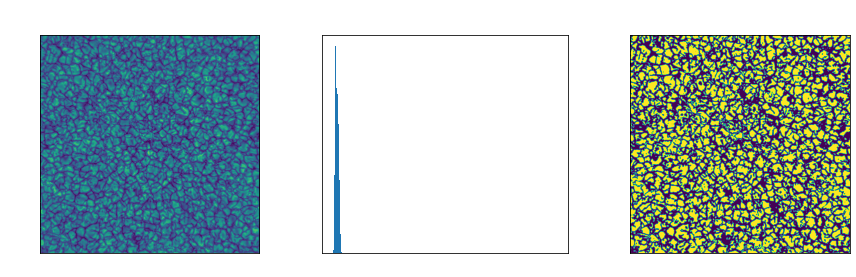

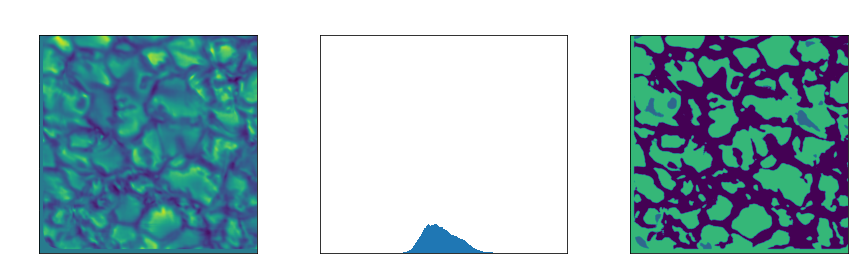

In [75]:
OG_data = fits.open("Data/DKIST_example.fits")[0].data
# OG_header = fits.open("Data/DKIST_example.fits")[0].header NOT CORRECT!!!
OG_data_seg = fits.open("Data/DKIST_solarseg_output.fits")[0].data
new_data = fits.open("Data/DKIST_gband_series_183653/VBI_2022_06_03T18_50_36_353_00430500_I_BPDWB_L1.fits")[1].data
new_header = fits.open("Data/DKIST_gband_series_183653/VBI_2022_06_03T18_50_36_353_00430500_I_BPDWB_L1.fits")[1].header
new_data_cut = fits.open("Data/SEG_VBI_2022_06_03T18_50_36_353_00430500_I_BPDWB_L1.fits")[1].data
new_data_seg_cut = fits.open("Data/SEG_VBI_2022_06_03T18_50_36_353_00430500_I_BPDWB_L1.fits")[0].data[0,:,:]
print(np.shape(new_data_seg_cut))

fig, (ax1, ax2, ax3) =  plt.subplots(1, 3, figsize=(15, 4))
axs = [ax1, ax2, ax3]
ax1.imshow(OG_data, origin='lower'); ax1.set_title('OG data', color=tc)
ax2.hist(OG_data.reshape(-1), range=(4000, 60000), bins=1000, density=True); ax2.set_title('OG data values', color=tc)
ax3.imshow(OG_data_seg, origin='lower'); ax3.set_title('OG data segmented (labels)', color=tc)
plt.suptitle('Res 0.017 arcsec/pix,  WL 789.2 nm', color=tc)
for ax in axs: ax.tick_params(labelcolor=tc, color=tc)

fig, (ax1, ax2, ax3) =  plt.subplots(1, 3, figsize=(15, 4))
axs = [ax1, ax2, ax3]
ax1.imshow(new_data_cut, origin='lower'); ax1.set_title('new data (cut)', color=tc)
ax2.hist(new_data_cut.reshape(-1), range=(4000, 60000), bins=1000, density=True); ax2.set_title('new data values', color=tc)
ax3.imshow(new_data_seg_cut, origin='lower'); ax3.set_title('new data segmented (labels)', color=tc)
plt.suptitle('Res '+str(np.round(new_header['cdelt1'], 3))+' arcsec/pix,  WL '+str(new_header['linewav'])+' nm', color=tc)
for ax in axs: ax.tick_params(labelcolor=tc, color=tc)

# NOTE
# 1) New images have similar spatial scale, but twice as many pixels -> much higher resolution
# 2) New images more blurred. Have wider pix value range, but its much less peaked, e.g more uniform
# 3) Segmentation is NOT working for new images.

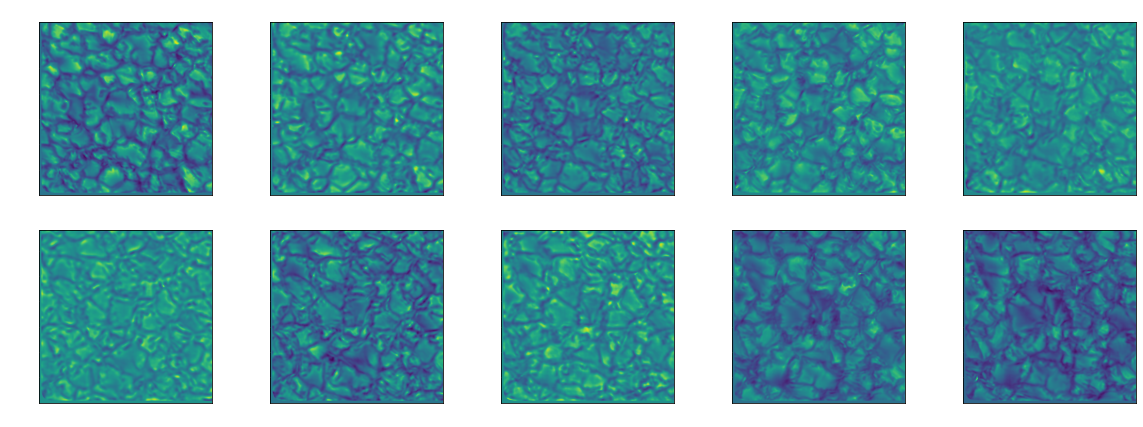

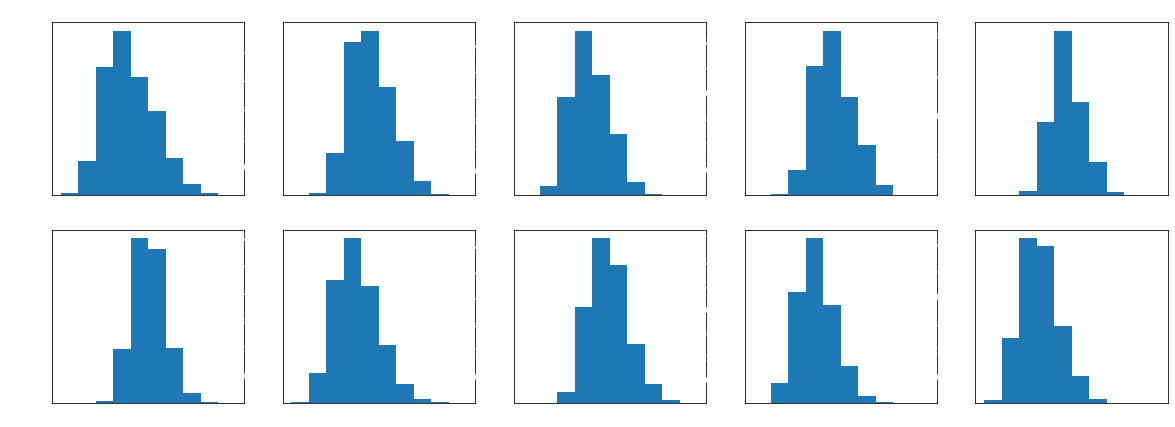

In [18]:
# Why does 53_20 seems to get stuck, even when cut down to sizes where the first two run fast??
# They all looks similar


dir = os.getcwd()+"/Data/DKIST_gband_series_183653/"
files = os.listdir(dir)

fig, ((ax1, ax2, ax3, ax4, ax5), (ax6, ax7, ax8, ax9, ax10)) =  plt.subplots(2, 5, figsize=(20, 7))
axs = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
i = 0
for file in files:
    if not (file.startswith('seg_') or file.startswith('SEG_')):
        data = fits.open(dir+file)[1].data # for files in DKIST_gband_series_183653, first HDU is just header
        data = data[0:int(np.shape(data)[0]/3), 0:int(np.shape(data)[1]/3)] # cut data by a factor of 9
        axs[i].imshow(data, origin='lower'); 
        label =  file[file.find('03T')+6:file.find('_00')-4] #print(label)
        axs[i].set_title(label, color=tc)
        i +=1
for ax in axs: ax.tick_params(labelcolor=tc, color=tc)


fig, ((ax1, ax2, ax3, ax4, ax5), (ax6, ax7, ax8, ax9, ax10)) =  plt.subplots(2, 5, figsize=(20, 7))
axs = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
i = 0
for file in files:
    if not (file.startswith('seg_') or file.startswith('SEG_')):
        data = fits.open(dir+file)[1].data # for files in DKIST_gband_series_183653, first HDU is just header
        data = data[0:int(np.shape(data)[0]/3), 0:int(np.shape(data)[1]/3)] # cut data by a factor of 9
        axs[i].hist(data.reshape(-1)); 
        label =  file[file.find('03T')+6:file.find('_00')-4] #print(label)
        axs[i].set_title(label, color=tc)
        i +=1
for ax in axs: ax.tick_params(labelcolor=tc, color=tc)

In [22]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np

file ="Data\DKIST_gband_series_183653\VBI_2022_06_03T18_50_36_353_00430500_I_BPDWB_L1.fits"
data = fits.open(file)[1].data # for files in DKIST_gband_series_183653, first HDU is just header
data = data[30:int(np.shape(data)[0]/10 +30 ), 30:int(np.shape(data)[1]/10)+30] # cut data by a factor of 10
header = fits.open(file)[1].header
hdu = fits.PrimaryHDU(data, header)
hdu = fits.HDUList([hdu])
hdu.writeto('TrueDKIST_example.fits', overwrite=True)

plt.imshow(fits.open("/mnt/c/Users/Lea/OneDrive/DKISTSegmentation/sunkit-image/TrueDKIST_example.fits"))


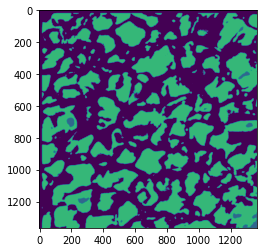

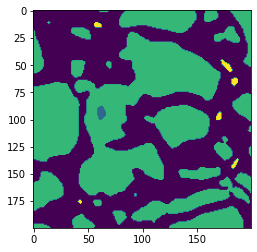

In [30]:
seg_50_36 = fits.open("Data\DKIST_gband_series_183653\SEG_VBI_2022_06_03T18_50_36_353_00430500_I_BPDWB_L1.fits")[0].data
seg_50_36 =  np.squeeze(seg_50_36)
plt.imshow(seg_50_36)

seg_noBPDMs = fits.open("Data/DKIST_solarseg_output_noBPDMs.fits")[0].data
seg_noBPDMs =  np.squeeze(seg_noBPDMs)
plt.figure()
plt.imshow(seg_noBPDMs[0:200, 0:200])